NameError: name 'lam' is not defined

Time stepper: RK4
Imag-axis cutoff |y| ≤ ycrit = 2.828427
FD2: max |φ(θ)| ≈ 0.999998 ⇒ CFL_max ≈ 2.828433
FD4: max |φ(θ)| ≈ 1.372222 ⇒ CFL_max ≈ 2.061203
PS : max |φ(θ)| ≈ 3.141592 ⇒ CFL_max ≈ 0.900317


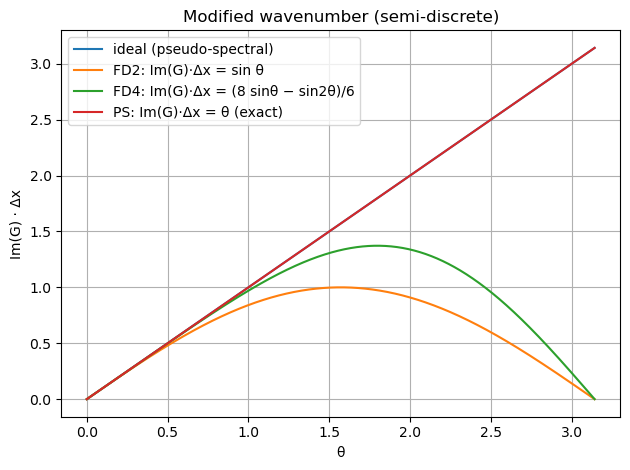

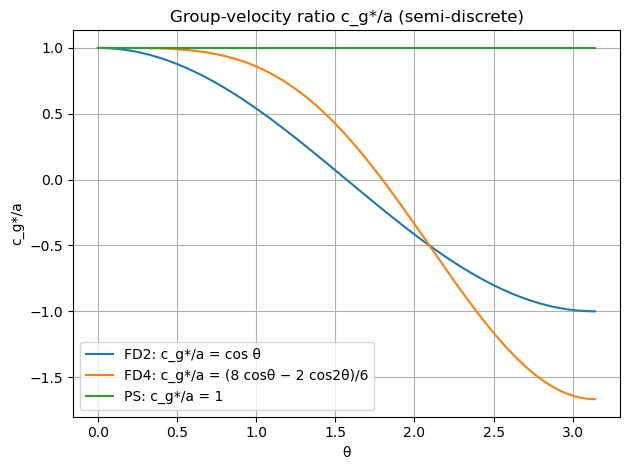

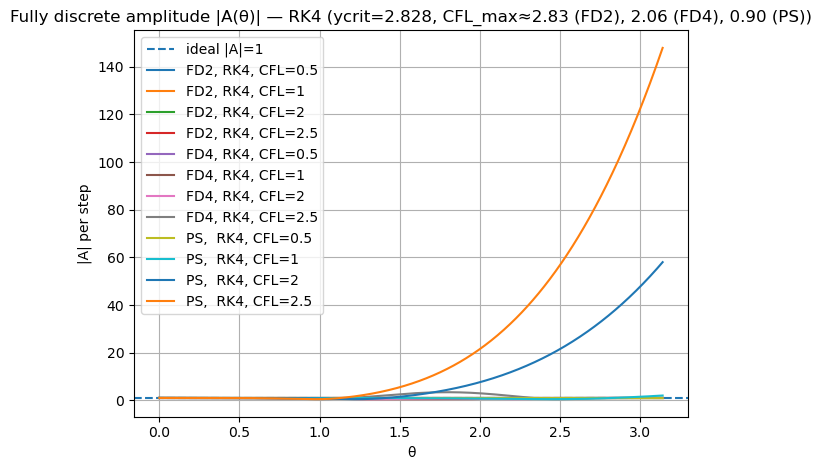

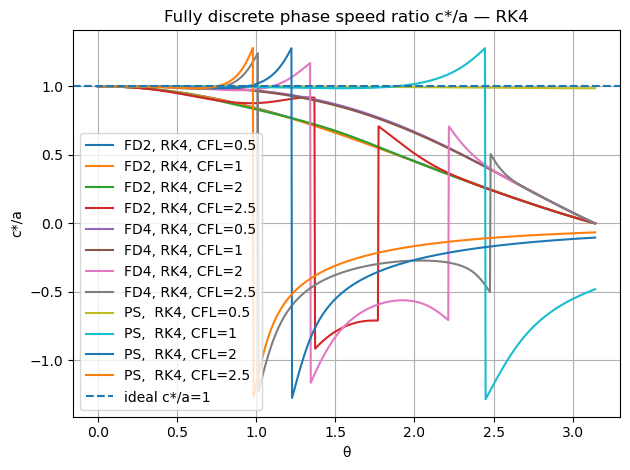

In [15]:
# dispersion_only_bspf_fd2_fd4_ps_optionA.py
# Focus: DISPERSION ONLY
# - Fix for last-point drop (Option A): restrict θ to the FFT's true top bin.
# - Compares bspf1d (spline + spectral residual) vs FD2, FD4, PS.
# - Plots: modified wavenumber and group-velocity ratio.

import numpy as np
import matplotlib.pyplot as plt
from math import pi

# ---- adjust this import to your layout ----
from bspf import bspf1d  # assumes your class is importable

# ------------------------- user params -------------------------
N = 1000           # grid points (large to isolate interior)
degree = 9         # spline degree
M_interior = 100   # interior averaging window for symbol estimation
n_theta = 500      # number of θ samples (we'll cap the upper end by theta_max)
# ---------------------------------------------------------------

# ---- FD & PS symbols: mw(θ) = Im(G)·Δx; group velocity = d(mw)/dθ ----
def mw_fd2(theta):   # FD2: (f_{j+1}-f_{j-1})/(2Δx)
    return np.sin(theta)

def mw_fd4(theta):   # FD4: (-f_{j+2}+8f_{j+1}-8f_{j-1}+f_{j-2})/(12Δx)
    return (8.0*np.sin(theta) - np.sin(2.0*theta)) / 6.0

def mw_ps(theta):    # Fourier pseudo-spectral
    return theta


# ---- bspf1d helpers ----
def build_bspf():
    x = np.linspace(0.0, 1.0, N)  # endpoint-inclusive grid is fine
    return bspf1d.from_grid(
        degree=degree,
        x=x,
        use_clustering=True,
        clustering_factor=2.0,
        correction="spectral",   # full operator: spline + spectral residual
    )

def differentiate_complex(b, arr, k=1, lam=0.0):
    # Combine two real runs; clear cached RHS each time to avoid stale '2bw'
    b._cached_arrays.clear()
    df_r, _ = b.differentiate(arr.real.astype(np.float64), k=k, lam=lam)
    b._cached_arrays.clear()
    df_i, _ = b.differentiate(arr.imag.astype(np.float64), k=k, lam=lam)
    return df_r + 1j * df_i

def interior_symbol_bspf(b, thetas, k=1, lam=0.0, M=256):
    N = b.grid.n
    j = np.arange(N)
    j0 = N // 2 - M // 2
    jj = np.arange(j0, j0 + M)

    G = np.zeros_like(thetas, dtype=np.complex128)
    for t, theta in enumerate(thetas):
        f = np.exp(1j * theta * j)
        df = differentiate_complex(b, f, k=k, lam=lam)
        G[t] = np.mean(df[jj] * np.exp(-1j * theta * jj))
    return G

# ---- build operator and set θ-range per Option A ----
b = build_bspf()
dx = b.grid.dx
# TRUE top reduced wavenumber supported by the rFFT grid:
theta_max = float(b.grid.omega[-1] * dx)  # omega = 2π * rfftfreq(N, d=dx)
# Sample θ safely below that cap (avoid Nyquist/leakage issues)
thetas = np.linspace(1e-4, theta_max, n_theta)

# ---- compute curves ----
# bspf modified wavenumber: mw_bspf = Im(G1) * Δx
G1_bspf = interior_symbol_bspf(b, thetas, k=1, M=M_interior)
mw_bspf = np.imag(G1_bspf) * dx
diss_bspf = np.real(G1_bspf) * dx  # should be ~0

# FD & PS curves on the trimmed θ-grid
mw2  = mw_fd2(thetas)
mw4  = mw_fd4(thetas)
mwp  = mw_ps(thetas)

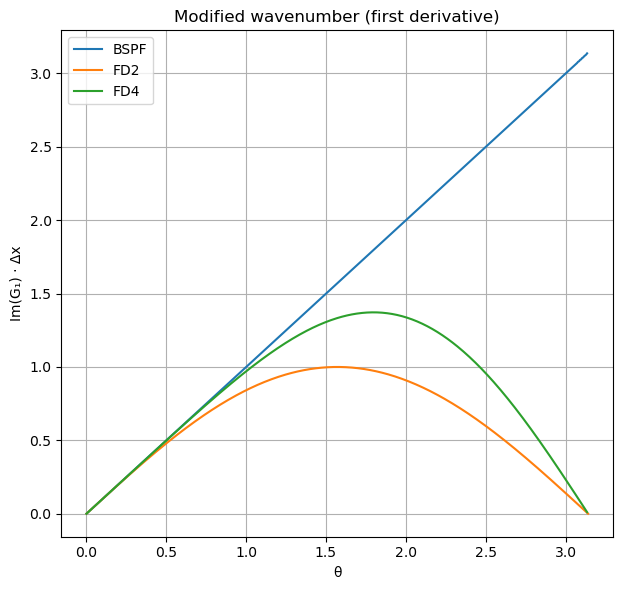

In [ ]:

# ============================ PLOTS ============================

# 1) Modified wavenumber
plt.figure(figsize=(12,6))
plt.subplot(1, 1, 1)
# plt.plot(thetas, thetas, label="ideal (pseudo-spectral)")
plt.plot(thetas[:-1], (mw_bspf[:-1]), label="BSPF")
plt.plot(thetas, mw2,     label="FD2")
plt.plot(thetas[:-1], mw4[:-1],     label="FD4")
# plt.plot(thetas, mwp,     label="PS (exact)")
plt.title("Modified wavenumber (first derivative)")
plt.xlabel("θ")
plt.ylabel("Im(G₁) · Δx")
plt.grid(True)
plt.legend()
plt.tight_layout()

# plt.subplot(1, 2, 2)
# # plt.plot(thetas, thetas, label="ideal (pseudo-spectral)")
# plt.plot(thetas[:-1], (diss_bspf[:-1]), label="BSPF")
# # plt.plot(thetas, mw2,     label="FD2")
# # plt.plot(thetas[:-1], mw4[:-1],     label="FD4")
# # plt.plot(thetas, mwp,     label="PS (exact)")
# plt.title("Modified wavenumber (first derivative)")
# plt.xlabel("θ")
# plt.ylabel("Im(G₁) · Δx")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()

plt.show()

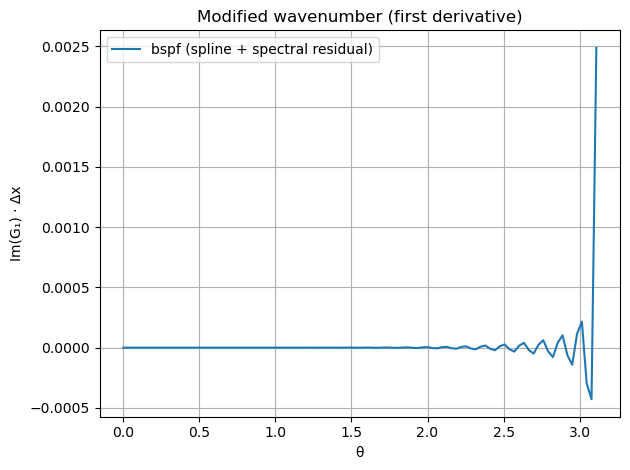

In [98]:
# ============================ PLOTS ============================

# 1) Modified wavenumber
plt.figure()
# plt.plot(thetas, thetas, label="ideal (pseudo-spectral)")
plt.plot(thetas[:-1], (mw_bspf[:-1]-thetas[:-1]), label="bspf (spline + spectral residual)")
# plt.plot(thetas, mw2,     label="FD2")
# plt.plot(thetas, mw4,     label="FD4")
# plt.plot(thetas, mwp,     label="PS (exact)")
plt.title("Modified wavenumber (first derivative)")
plt.xlabel("θ")
plt.ylabel("Im(G₁) · Δx")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


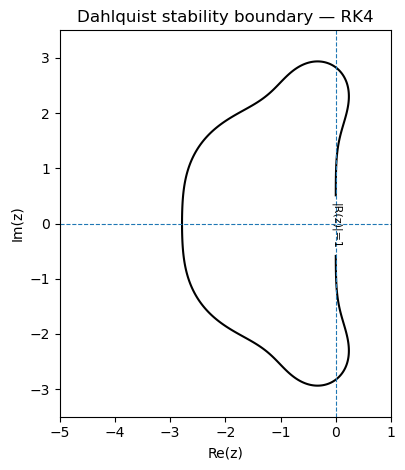

In [26]:
# dahlquist_boundary_curve.py
import numpy as np
import matplotlib.pyplot as plt

TIME_STEPPER = "RK4"  # "RK4", "SSPRK3", "RK2", or "FE"

def R(z, kind):
    if kind=="FE":      return 1 + z
    if kind=="RK2":     return 1 + z + 0.5*z**2
    if kind=="SSPRK3":  return 1 + z + 0.5*z**2 + (1/6)*z**3
    if kind=="RK4":     return 1 + z + 0.5*z**2 + (1/6)*z**3 + (1/24)*z**4
    raise ValueError

# sample a box in the complex plane and draw ONLY the |R(z)|=1 contour
xr = np.linspace(-5, 1, 1200)   # real axis
yi = np.linspace(-3.5, 3.5, 1200)  # imaginary axis
X, Y = np.meshgrid(xr, yi)
Z = X + 1j*Y
AMP = np.abs(R(Z, TIME_STEPPER))

plt.figure()
cs = plt.contour(X, Y, AMP, levels=[1.0], colors="k")
plt.clabel(cs, fmt="|R(z)|=1", inline=True, fontsize=8)
plt.axhline(0, linestyle="--", linewidth=0.8)
plt.axvline(0, linestyle="--", linewidth=0.8)
plt.gca().set_aspect("equal", adjustable="box")
plt.title(f"Dahlquist stability boundary — {TIME_STEPPER}")
plt.xlabel("Re(z)")
plt.ylabel("Im(z)")
plt.tight_layout()
plt.show()


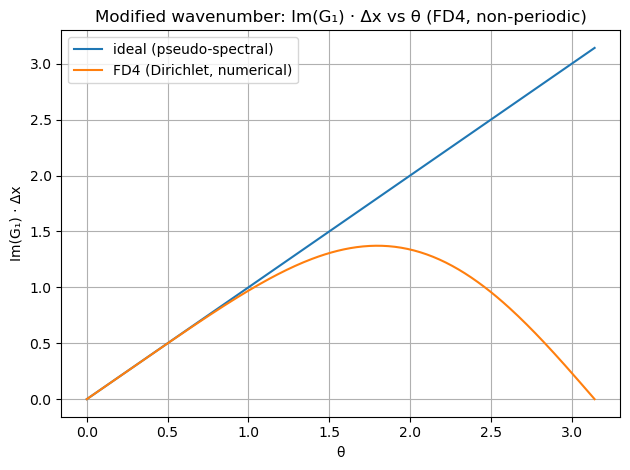

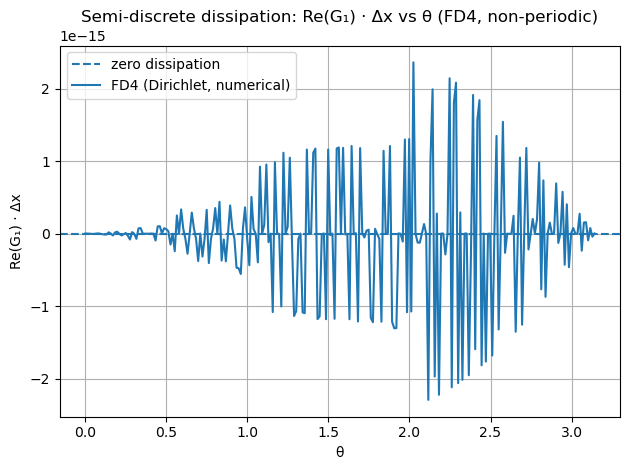

In [115]:
# fd4_dirichlet_dispersion_dissipation.py
# Numerically measure dispersion (modified wavenumber) and dissipation (Re symbol)
# for the 4th-order central-difference derivative (FD4), *without* periodic wrap.
# Boundary handling: no wraparound; we compute the derivative only where the
# 5-point central stencil fits (i=2..N-3) and ignore the boundary layers by
# averaging over a centered interior window.

import numpy as np
import matplotlib.pyplot as plt

# ---------------- user parameters ----------------
N = 4097            # grid size (large so interior is far from boundaries)
M_INTERIOR = 256    # width of centered interior window used for averaging
N_THETA = 240       # number of theta samples in (0, pi)
ENFORCE_DIRICHLET = True  # set f[0]=f[-1]=0 before applying the operator
# -------------------------------------------------

def fd4_apply_dirichlet(f: np.ndarray, dx: float) -> np.ndarray:
    """
    Apply the *non-periodic* 4th-order central difference derivative.
    Uses the 5-point central stencil only on indices i=2..N-3.
    Leaves boundary-adjacent rows as NaN (so they are ignored in the interior average).
    """
    f = np.asarray(f)
    df = np.full(f.shape, np.nan, dtype=np.complex128)
    # central 5-point (4th-order) stencil for first derivative
    # df[i] = (-f[i+2] + 8 f[i+1] - 8 f[i-1] + f[i-2]) / (12 dx)
    i0, i1 = 2, f.size - 3
    df[i0:i1] = (-f[i0+2:i1+2] + 8.0*f[i0+1:i1+1] - 8.0*f[i0-1:i1-1] + f[i0-2:i1-2]) / (12.0*dx)
    return df

def interior_symbol_fd4(N: int, M: int, n_theta: int, enforce_dirichlet: bool):
    """
    Return theta grid, numerical interior symbol G(θ), and dx.
    G(θ) is estimated by averaging the local multiplier over a centered interior window.
    """
    x = np.linspace(0.0, 1.0, N)         # endpoint-inclusive (non-periodic) grid
    dx = x[1] - x[0]
    j  = np.arange(N)

    # interior window (center of the domain, far from boundaries)
    j0 = N//2 - M//2
    jwin = np.arange(j0, j0+M)

    # theta grid (avoid endpoints)
    thetas = np.linspace(1e-4, np.pi - 1e-4, n_theta)

    G = np.zeros_like(thetas, dtype=np.complex128)
    for t, theta in enumerate(thetas):
        f = np.exp(1j * theta * j)
        if enforce_dirichlet:
            f = f.copy()
            f[0] = 0.0
            f[-1] = 0.0

        df = fd4_apply_dirichlet(f, dx)
        # local multiplier A_j = (D f)_j * e^{-i theta j}
        A = df * np.exp(-1j * theta * j)
        # average over the interior window (ignoring NaNs by construction)
        G[t] = np.nanmean(A[jwin])

    return thetas, G, dx

def main():
    thetas, G, dx = interior_symbol_fd4(N, M_INTERIOR, N_THETA, ENFORCE_DIRICHLET)

    # Dispersion (modified wavenumber): Im(G)*Δx vs θ
    mw = np.imag(G) * dx
    # Dissipation: Re(G)*Δx vs θ
    diss = np.real(G) * dx

    # ---- Plot 1: Modified wavenumber (dispersion) ----
    plt.figure()
    plt.plot(thetas, thetas, label="ideal (pseudo-spectral)")
    plt.plot(thetas, mw, label="FD4 (Dirichlet, numerical)")
    plt.title("Modified wavenumber: Im(G₁) · Δx vs θ (FD4, non-periodic)")
    plt.xlabel("θ")
    plt.ylabel("Im(G₁) · Δx")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    # ---- Plot 2: Dissipation ----
    plt.figure()
    plt.axhline(0.0, linestyle="--", label="zero dissipation")
    plt.plot(thetas, diss, label="FD4 (Dirichlet, numerical)")
    plt.title("Semi-discrete dissipation: Re(G₁) · Δx vs θ (FD4, non-periodic)")
    plt.xlabel("θ")
    plt.ylabel("Re(G₁) · Δx")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.show()

if __name__ == "__main__":
    main()
